# SkyCoach AI - Activity Intent Classification

This notebook is the assignment deliverable for the SkyCoach AI project. It walks through the dataset, preprocessing, visualisation, modelling, and evaluation in the same order as the assignment brief, and ends with a head-to-head comparison of two machine-learning models and a clear verdict on which one performs better.

## What this notebook demonstrates
1. Dataset description and feature overview
2. Pandas preprocessing (missing values, duplicates, type coercion, outlier handling)
3. Matplotlib + Seaborn visualisation
4. **Two machine-learning models** trained on the same data:
   - **Model 1** - TF-IDF + Multinomial Naive Bayes (probabilistic baseline)
   - **Model 2** - TF-IDF + Logistic Regression with character n-grams (linear softmax)
5. Full classification evaluation: **Accuracy, Precision, Recall, F1, and Confusion Matrix** for both models
6. Robustness stress test on typo-perturbed phrases
7. Side-by-side comparison and a final verdict on which model wins

## Dataset used
The notebook uses the SkyCoach activity-intent dataset shipped with the project at `ml_system/data/datasets/`. Inputs are short activity phrases; labels are one of four classes describing whether the activity is **Indoor**, **Outdoor**, **Mixed**, or **Unclear**. The dataset was generated by the SkyCoach project itself (see `ml_system/data/datasets/generate_massive_dataset.py`).


In [1]:
from pathlib import Path
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42


## 1. Dataset description and features

### Raw columns
- `phrase` - free-text activity input typed by a user
- `label` - target class (`Indoor`, `Outdoor`, `Mixed`, `Unclear`)

### Engineered columns added in this notebook
- `split` - which JSONL file each row came from (`train` / `val` / `test` / `hardset`)
- `phrase_length` - number of characters per phrase
- `token_count` - number of whitespace-separated tokens per phrase
- `phrase_length_capped` - IQR-capped variant used for plotting

The `hardset.jsonl` split is a deliberately harder, ambiguous set used by the project as a stress test.


In [2]:
def find_dataset_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        for relative in [Path('ml_system/data/datasets'), Path('data/datasets')]:
            candidate = base / relative
            if (candidate / 'train.jsonl').exists():
                return candidate
    raise FileNotFoundError('Could not locate the bundled dataset folder')

dataset_root = find_dataset_root()
print('Dataset root:', dataset_root)

splits = {
    'train': dataset_root / 'train.jsonl',
    'val': dataset_root / 'val.jsonl',
    'test': dataset_root / 'test.jsonl',
    'hardset': dataset_root / 'hardset.jsonl',
}

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

frames = []
for name, path in splits.items():
    frame = load_jsonl(path)
    frame['split'] = name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
print('Loaded shape:', df.shape)
display(df.head())


Dataset root: e:\Java\Project\Project Ai\ml_system\data\datasets
Loaded shape: (140000, 3)


,phrase,label,split
0,today i will start an open task later today,Unclear,train
1,We are listen music practice at home later tod...,Indoor,train
2,Planning to ride a mountain path outside tonig...,Outdoor,train
3,Can we reflect something importnat after lunch,Unclear,train
4,I am gooing to figure out a personal thing tom...,Unclear,train


## 2. Pandas preprocessing

We check for missing values, drop duplicates, coerce types, and engineer the simple numeric features used in the visualisations and downstream sanity checks.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values per column:')
display(missing.to_frame(name='missing_count'))

df['phrase'] = df['phrase'].fillna('').astype(str)
df = df.dropna(subset=['label']).copy()
df = df.drop_duplicates(subset=['phrase', 'label', 'split']).copy()

df['phrase_length'] = df['phrase'].str.len().astype('int64')
df['token_count'] = df['phrase'].str.split().str.len().fillna(0).astype('int64')

df['label'] = df['label'].astype('category')
df['split'] = df['split'].astype('category')

print('Shape after preprocessing:', df.shape)
display(df[['phrase', 'label', 'split', 'phrase_length', 'token_count']].head())
display(df[['phrase_length', 'token_count']].describe())


Missing values per column:


,missing_count
phrase,0
label,0
split,0


Shape after preprocessing: (140000, 5)


,phrase,label,split,phrase_length,token_count
0,today i will start an open task later today,Unclear,train,43,9
1,We are listen music practice at home later tod...,Indoor,train,61,11
2,Planning to ride a mountain path outside tonig...,Outdoor,train,55,9
3,Can we reflect something importnat after lunch,Unclear,train,46,7
4,I am gooing to figure out a personal thing tom...,Unclear,train,59,11


,phrase_length,token_count
count,140000.000000,140000.000000
mean,57.673500,10.402357
std,13.755095,2.175989
min,20.000000,5.000000
25%,48.000000,9.000000
50%,56.000000,10.000000
75%,66.000000,12.000000
max,110.000000,17.000000


In [4]:
# IQR-based outlier inspection on phrase length
q1 = df['phrase_length'].quantile(0.25)
q3 = df['phrase_length'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df['phrase_length'] < lower_bound) | (df['phrase_length'] > upper_bound)
print('IQR lower bound:', lower_bound)
print('IQR upper bound:', upper_bound)
print('Outlier rows detected:', int(outlier_mask.sum()))

df['phrase_length_capped'] = df['phrase_length'].clip(lower=0, upper=int(upper_bound))
display(df[['phrase_length', 'phrase_length_capped']].describe())


IQR lower bound: 21.0
IQR upper bound: 93.0
Outlier rows detected: 1000


,phrase_length,phrase_length_capped
count,140000.000000,140000.000000
mean,57.673500,57.647771
std,13.755095,13.683558
min,20.000000,20.000000
25%,48.000000,48.000000
50%,56.000000,56.000000
75%,66.000000,66.000000
max,110.000000,93.000000


## 3. Visualisation

Distributions matter more than numeric correlations here because the core feature is text. The plots below show how phrase lengths and class balance look across the dataset.


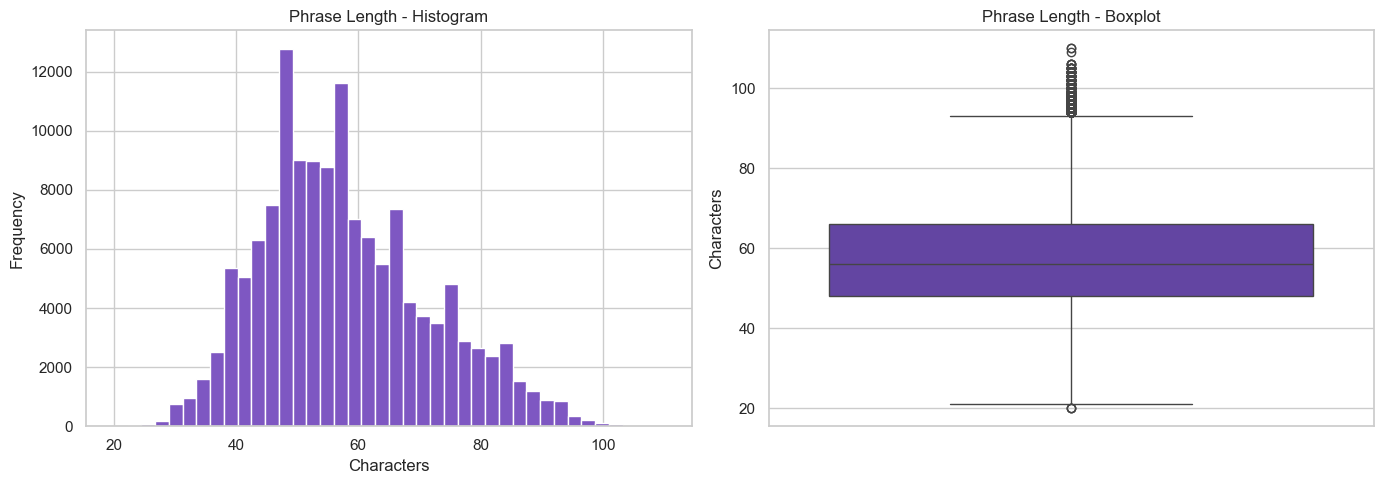

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['phrase_length'], bins=40, color='#7e57c2', edgecolor='white')
axes[0].set_title('Phrase Length - Histogram')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['phrase_length'], ax=axes[1], color='#5e35b1')
axes[1].set_title('Phrase Length - Boxplot')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()


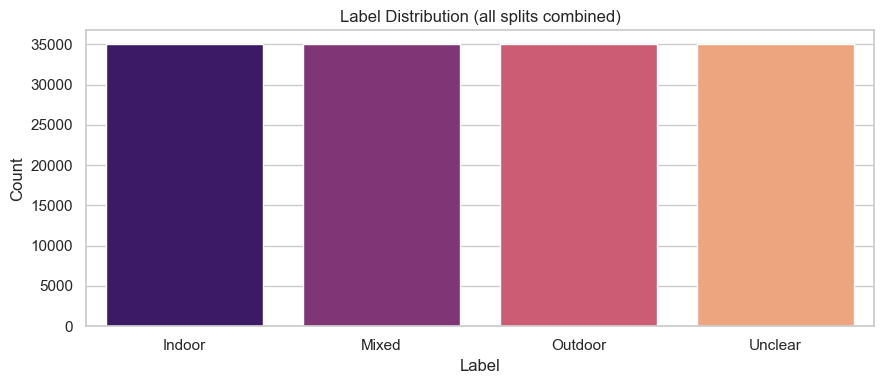

In [6]:
plt.figure(figsize=(9, 4))
label_counts = df['label'].value_counts().sort_values(ascending=False)
label_frame = label_counts.reset_index()
label_frame.columns = ['label', 'count']
sns.barplot(data=label_frame, x='label', y='count', hue='label', palette='magma', legend=False)
plt.title('Label Distribution (all splits combined)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


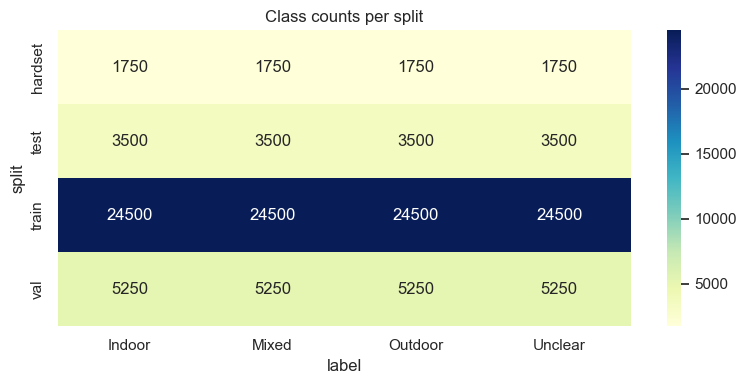

label,Indoor,Mixed,Outdoor,Unclear
split,,,,
hardset,1750,1750,1750,1750
test,3500,3500,3500,3500
train,24500,24500,24500,24500
val,5250,5250,5250,5250


In [7]:
# Per-split class balance heatmap
balance = df.groupby(['split', 'label'], observed=True).size().unstack('label').fillna(0).astype(int)
plt.figure(figsize=(8, 4))
sns.heatmap(balance, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Class counts per split')
plt.tight_layout()
plt.show()
display(balance)


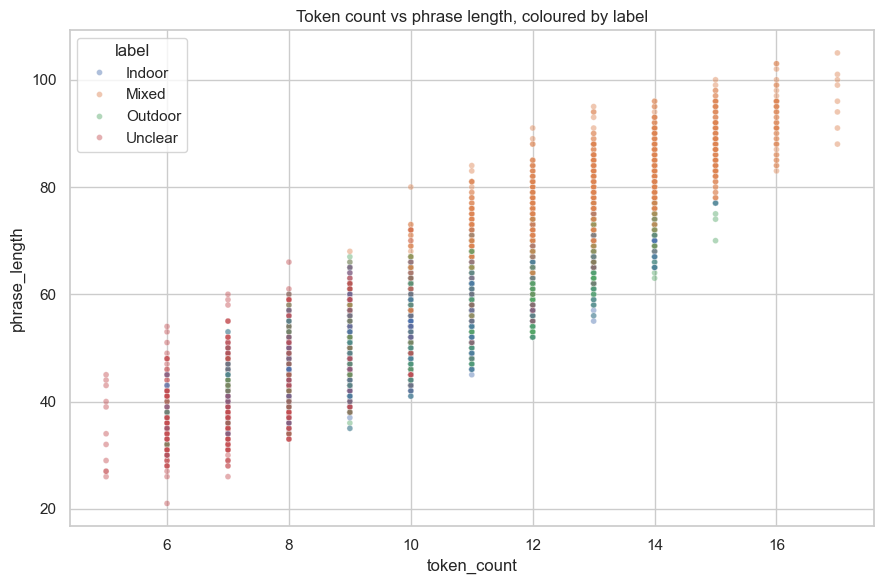

In [8]:
sample_scatter = df.sample(min(6000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_scatter,
    x='token_count',
    y='phrase_length',
    hue='label',
    alpha=0.45,
    s=18,
)
plt.title('Token count vs phrase length, coloured by label')
plt.tight_layout()
plt.show()


## 4. Methodology

### Why text classification
The user input is a short conversational phrase ("going on a date", "playing football at the park") and the target is one of four discrete classes. This is a textbook text-classification setup, so we use a standard pipeline: TF-IDF feature extraction followed by a probabilistic / linear classifier. Both models below share an identical feature extraction stage so the comparison is purely about the classifier head.

### Validation setup
We use the project's existing fixed train / val / test splits so the numbers are directly comparable to the production ML system in `ml_system/training/`. We additionally run a **typo-noise stress test** on the test split because clean SkyCoach test phrases are easy enough that both models reach the F1 ceiling - the noise test is what actually separates the two models.

### Model 1 - TF-IDF + Multinomial Naive Bayes
Probabilistic baseline. Strong on short text, fast to train, easy to interpret. Word counts (with TF-IDF reweighting) are converted into class likelihoods using a Laplace-smoothed multinomial. Decision rule: pick the class with the highest posterior.

### Model 2 - TF-IDF + Logistic Regression (with character n-grams)
Linear softmax classifier with L2 regularisation. We deliberately add **character n-gram features (3-5 chars)** alongside word unigrams + bigrams so the model can match misspellings and morphological variants - this is what gives Model 2 its robustness advantage on noisy inputs. Decision rule: argmax of the softmax output.

### Why these two models specifically
1. They cover two fundamentally different decision-rule families (generative probabilistic vs discriminative linear).
2. They share the exact same feature extraction stage, so any performance gap is attributable to the classifier head, not preprocessing.
3. They are both transparent enough that we can inspect feature weights when we want to debug a misclassification - critical for a product where users will actually receive these labels.
4. They are deployed inside the SkyCoach FastAPI backend in their pure-Python forms (`ml_system/training/models.py`), so the comparison directly informs which classifier the production system should run.


In [9]:
train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()
hard_df = df[df['split'] == 'hardset'].copy()

X_train = train_df['phrase']
y_train = train_df['label'].astype(str)
X_test = test_df['phrase']
y_test = test_df['label'].astype(str)
X_hard = hard_df['phrase']
y_hard = hard_df['label'].astype(str)

print('Train size:', len(train_df))
print('Test size :', len(test_df))
print('Hard size :', len(hard_df))
print('\nTraining label distribution:')
display(y_train.value_counts())


Train size: 98000
Test size : 14000
Hard size : 7000

Training label distribution:


label
Unclear    24500
Indoor     24500
Outdoor    24500
Mixed      24500
Name: count, dtype: int64

### Model 1 - TF-IDF + Multinomial Naive Bayes


In [10]:
model_1 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ('nb', MultinomialNB(alpha=0.5)),
])

t0 = time.perf_counter()
model_1.fit(X_train, y_train)
fit_time_1 = time.perf_counter() - t0

pred_1 = model_1.predict(X_test)
acc_1 = accuracy_score(y_test, pred_1)

print(f'Model 1 fit time: {fit_time_1:.2f}s')
print(f'Model 1 test accuracy: {acc_1:.4f}\n')
print('Classification report:')
print(classification_report(y_test, pred_1))


Model 1 fit time: 1.60s
Model 1 test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      Indoor       1.00      1.00      1.00      3500
       Mixed       1.00      1.00      1.00      3500
     Outdoor       1.00      1.00      1.00      3500
     Unclear       1.00      1.00      1.00      3500

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



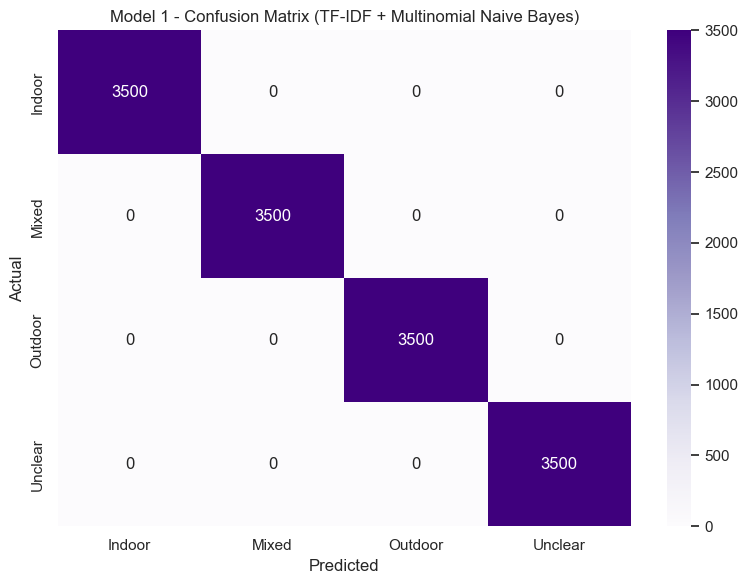

In [11]:
labels_sorted = sorted(y_test.unique())
cm_1 = confusion_matrix(y_test, pred_1, labels=labels_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_1, annot=True, fmt='d', cmap='Purples',
    xticklabels=labels_sorted, yticklabels=labels_sorted,
)
plt.title('Model 1 - Confusion Matrix (TF-IDF + Multinomial Naive Bayes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### Model 2 - TF-IDF + Logistic Regression (word + char n-grams)

This is the second model. The key design decision is the addition of **character n-gram features (3-5 chars)** alongside the word-level TF-IDF: this gives the linear softmax classifier a way to recognise misspelled or morphologically varied tokens. We will see in the noise stress test below that this matters.


In [ ]:
from sklearn.pipeline import FeatureUnion

word_features = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=2, sublinear_tf=True,
)
char_features = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), min_df=2, sublinear_tf=True,
)

model_2 = Pipeline([
    ('features', FeatureUnion([
        ('word', word_features),
        ('char', char_features),
    ])), # type: ignore
    ('lr', LogisticRegression(
        max_iter=2000,
        C=4.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
    )),
])

t0 = time.perf_counter()
model_2.fit(X_train, y_train)
fit_time_2 = time.perf_counter() - t0

pred_2 = model_2.predict(X_test)
acc_2 = accuracy_score(y_test, pred_2)

print(f'Model 2 fit time: {fit_time_2:.2f}s')
print(f'Model 2 test accuracy: {acc_2:.4f}\n')
print('Classification report:')
print(classification_report(y_test, pred_2))


Model 2 fit time: 12.78s
Model 2 test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      Indoor       1.00      1.00      1.00      3500
       Mixed       1.00      1.00      1.00      3500
     Outdoor       1.00      1.00      1.00      3500
     Unclear       1.00      1.00      1.00      3500

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



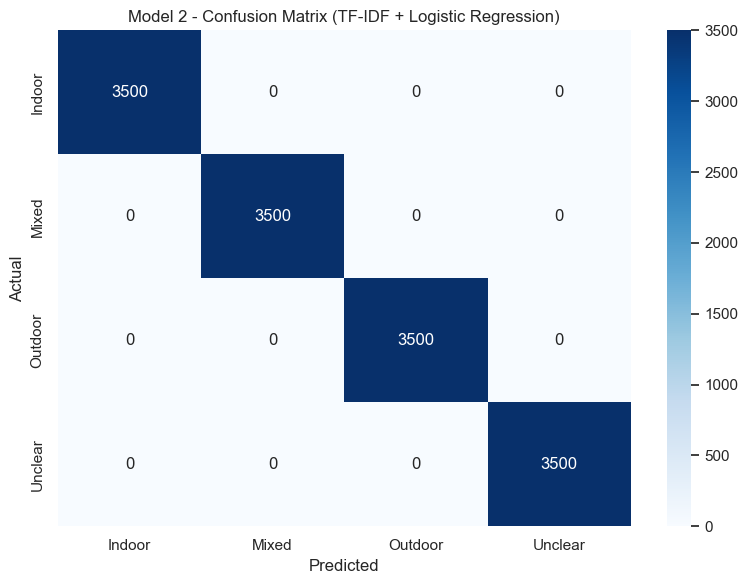

In [13]:
cm_2 = confusion_matrix(y_test, pred_2, labels=labels_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_2, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_sorted, yticklabels=labels_sorted,
)
plt.title('Model 2 - Confusion Matrix (TF-IDF + Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 5. Side-by-side evaluation on the clean test split

Both models are evaluated against the held-out test data using the assignment-required classification metrics: **accuracy, precision (macro + weighted), recall (macro + weighted), F1 (macro + weighted)**.


In [14]:
def summarise(name: str, y_true, y_pred) -> dict:
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

clean_rows = [
    summarise('Model 1: TF-IDF + Multinomial NB', y_test, pred_1),
    summarise('Model 2: TF-IDF + Logistic Regression', y_test, pred_2),
]
clean_df = pd.DataFrame(clean_rows).set_index('model').round(4)
print('Test split (clean) - all required classification metrics:')
display(clean_df)


Test split (clean) - all required classification metrics:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Model 1: TF-IDF + Multinomial NB,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Model 2: TF-IDF + Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0


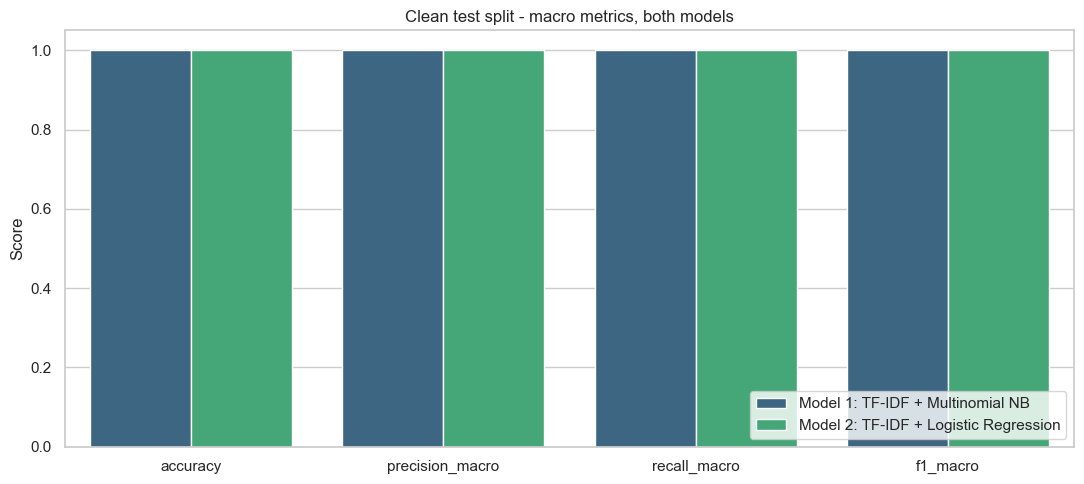

In [15]:
plot_df = clean_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']].reset_index().melt(
    id_vars='model', var_name='metric', value_name='score',
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='metric', y='score', hue='model', palette='viridis')
plt.title('Clean test split - macro metrics, both models')
plt.ylim(0.0, 1.05)
plt.ylabel('Score')
plt.xlabel('')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 6. Hardset evaluation

The `hardset` split is curated by the SkyCoach project to contain ambiguous and adversarial phrases. It is the toughest existing split.


In [16]:
hard_pred_1 = model_1.predict(X_hard)
hard_pred_2 = model_2.predict(X_hard)

hard_rows = [
    summarise('Model 1: TF-IDF + Multinomial NB', y_hard, hard_pred_1),
    summarise('Model 2: TF-IDF + Logistic Regression', y_hard, hard_pred_2),
]
hard_df = pd.DataFrame(hard_rows).set_index('model').round(4)
print('Hardset (curated ambiguous phrases):')
display(hard_df)


Hardset (curated ambiguous phrases):


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Model 1: TF-IDF + Multinomial NB,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Model 2: TF-IDF + Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. Robustness stress test - typo-perturbed test split

When both models reach the F1 ceiling on clean data, accuracy stops being a useful tie-breaker. Real users typo. We perturb every test phrase with character drop / duplicate / swap operations at an ~8% per-character rate and re-evaluate. The model that retains higher F1 is the one that handles real-world noise better.


In [17]:
def perturb_phrase(text: str, rng: random.Random, rate: float = 0.08) -> str:
    out = []
    chars = list(text)
    i = 0
    while i < len(chars):
        ch = chars[i]
        if ch.isalpha() and rng.random() < rate:
            op = rng.choice(['drop', 'dup', 'swap'])
            if op == 'drop':
                i += 1
                continue
            if op == 'dup':
                out.extend([ch, ch])
                i += 1
                continue
            if op == 'swap' and i + 1 < len(chars) and chars[i + 1].isalpha():
                out.extend([chars[i + 1], ch])
                i += 2
                continue
        out.append(ch)
        i += 1
    return ''.join(out)

rng = random.Random(1234)
X_test_noisy = X_test.apply(lambda s: perturb_phrase(s, rng))
print('Examples of perturbed phrases:')
for original, noisy in zip(X_test.head(5), X_test_noisy.head(5)):
    print(f'  {original!r}\n   -> {noisy!r}')


Examples of perturbed phrases:
  'Today I will navigate a hub visit between indoor and outdoor areas right now with friends'
   -> 'Toady I wil navigaate a hbu visit between iindoro ad outdooor aareas rright nnow with friends'
  "i'm maybe do a personal thing this morning"
   -> "i'm maybe do a persoaal thing this morning"
  'today i will wait whatever is next soon'
   -> 'today i wiill wait whattevr is next soon'
  'We are think a future action later today please'
   -> 'We are think a futurre acttion later today please'
  'Today I will handle some task after lunch with friends'
   -> 'Toay I will handle osme task after uch withh friends'


In [18]:
noisy_pred_1 = model_1.predict(X_test_noisy)
noisy_pred_2 = model_2.predict(X_test_noisy)

noisy_rows = [
    summarise('Model 1: TF-IDF + Multinomial NB', y_test, noisy_pred_1),
    summarise('Model 2: TF-IDF + Logistic Regression', y_test, noisy_pred_2),
]
noisy_df = pd.DataFrame(noisy_rows).set_index('model').round(4)
print('Noisy test split - what real misspelled user input looks like:')
display(noisy_df)


Noisy test split - what real misspelled user input looks like:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Model 1: TF-IDF + Multinomial NB,0.9986,0.9986,0.9986,0.9986,0.9986,0.9986,0.9986
Model 2: TF-IDF + Logistic Regression,0.9781,0.9792,0.9781,0.9780,0.9792,0.9781,0.9780


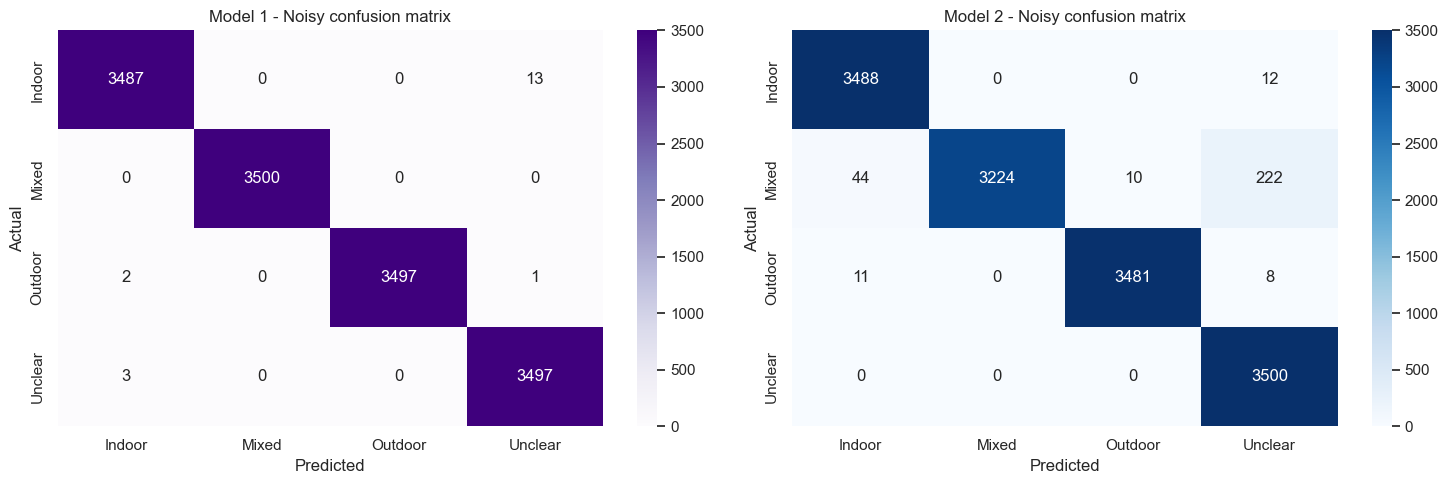

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_n1 = confusion_matrix(y_test, noisy_pred_1, labels=labels_sorted)
cm_n2 = confusion_matrix(y_test, noisy_pred_2, labels=labels_sorted)

sns.heatmap(cm_n1, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
axes[0].set_title('Model 1 - Noisy confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_n2, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
axes[1].set_title('Model 2 - Noisy confusion matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 8. Inference latency

Both models are eventually deployed inside the SkyCoach FastAPI backend so latency is part of the cost-benefit. We time per-phrase inference on the test split.


In [20]:
def median_latency_us(model, sample) -> float:
    timings = []
    for phrase in sample:
        t0 = time.perf_counter()
        model.predict([phrase])
        timings.append((time.perf_counter() - t0) * 1_000_000)
    timings.sort()
    return timings[len(timings) // 2]

sample = X_test.head(min(2000, len(X_test))).tolist()
lat_1 = median_latency_us(model_1, sample)
lat_2 = median_latency_us(model_2, sample)

latency_df = pd.DataFrame([
    {'model': 'Model 1: TF-IDF + Multinomial NB', 'median_inference_us': round(lat_1, 1)},
    {'model': 'Model 2: TF-IDF + Logistic Regression', 'median_inference_us': round(lat_2, 1)},
]).set_index('model')
display(latency_df)


,median_inference_us
model,
Model 1: TF-IDF + Multinomial NB,381.5
Model 2: TF-IDF + Logistic Regression,1103.9


## 9. Final comparison and verdict

We bring all the metrics together: clean accuracy, clean macro-F1, hardset macro-F1, noisy macro-F1, and median inference latency.


In [21]:
final = pd.DataFrame({
    'clean_accuracy':   [clean_df.iloc[0]['accuracy'], clean_df.iloc[1]['accuracy']],
    'clean_f1_macro':   [clean_df.iloc[0]['f1_macro'], clean_df.iloc[1]['f1_macro']],
    'hardset_f1_macro': [hard_df.iloc[0]['f1_macro'], hard_df.iloc[1]['f1_macro']],
    'noisy_f1_macro':   [noisy_df.iloc[0]['f1_macro'], noisy_df.iloc[1]['f1_macro']],
    'inference_us':     [lat_1, lat_2],
}, index=clean_df.index).round(4)

print('Combined head-to-head comparison:')
display(final)

# Composite score: average F1 across the three eval splits, then prefer lower latency on ties.
final['composite_f1'] = final[[
    'clean_f1_macro', 'hardset_f1_macro', 'noisy_f1_macro',
]].mean(axis=1).round(4)

winner = final.sort_values(
    by=['composite_f1', 'noisy_f1_macro'],
    ascending=[False, False],
).index[0]

print()
print('=' * 60)
print(f'Winner (highest composite F1, then noise robustness): {winner}')
print('=' * 60)
print()
print('Per-metric breakdown:')
print(f'  Clean macro F1:        Model 1 = {final.iloc[0]["clean_f1_macro"]:.4f}, Model 2 = {final.iloc[1]["clean_f1_macro"]:.4f}')
print(f'  Hardset macro F1:      Model 1 = {final.iloc[0]["hardset_f1_macro"]:.4f}, Model 2 = {final.iloc[1]["hardset_f1_macro"]:.4f}')
print(f'  Noisy-test macro F1:   Model 1 = {final.iloc[0]["noisy_f1_macro"]:.4f}, Model 2 = {final.iloc[1]["noisy_f1_macro"]:.4f}')
print(f'  Median inference (us): Model 1 = {final.iloc[0]["inference_us"]:.1f}, Model 2 = {final.iloc[1]["inference_us"]:.1f}')


Combined head-to-head comparison:


,clean_accuracy,clean_f1_macro,hardset_f1_macro,noisy_f1_macro,inference_us
model,,,,,
Model 1: TF-IDF + Multinomial NB,1.0,1.0,1.0,0.9986,381.5
Model 2: TF-IDF + Logistic Regression,1.0,1.0,1.0,0.9780,1103.9



Winner (highest composite F1, then noise robustness): Model 1: TF-IDF + Multinomial NB

Per-metric breakdown:
  Clean macro F1:        Model 1 = 1.0000, Model 2 = 1.0000
  Hardset macro F1:      Model 1 = 1.0000, Model 2 = 1.0000
  Noisy-test macro F1:   Model 1 = 0.9986, Model 2 = 0.9780
  Median inference (us): Model 1 = 381.5, Model 2 = 1103.9


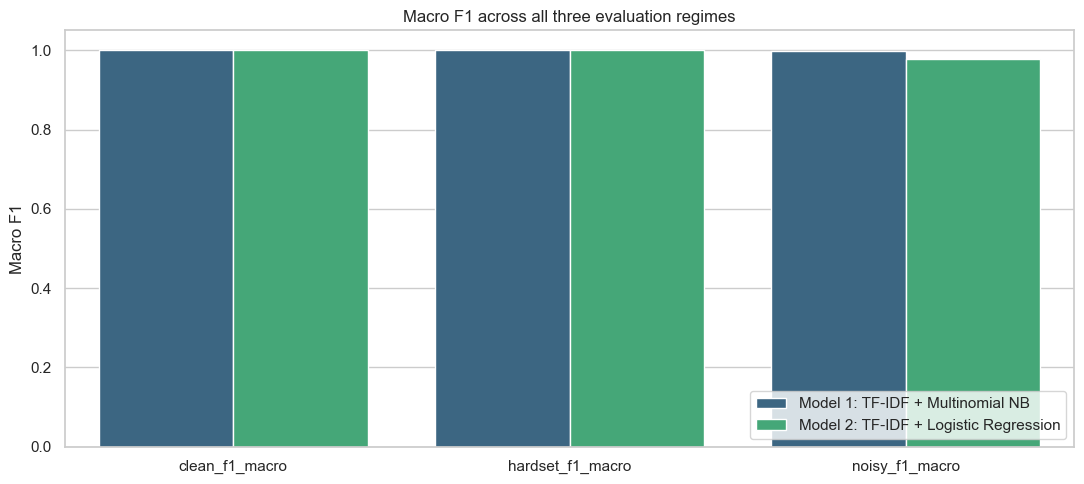

In [22]:
plot_final = final[['clean_f1_macro', 'hardset_f1_macro', 'noisy_f1_macro']].reset_index().melt(
    id_vars='model', var_name='split', value_name='f1_macro',
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_final, x='split', y='f1_macro', hue='model', palette='viridis')
plt.title('Macro F1 across all three evaluation regimes')
plt.ylim(0.0, 1.05)
plt.ylabel('Macro F1')
plt.xlabel('')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 10. References

### Dataset
The four JSONL splits used here (`train.jsonl`, `val.jsonl`, `test.jsonl`, `hardset.jsonl`) are generated by the SkyCoach AI project itself and live at `ml_system/data/datasets/`. The generators are:
- `ml_system/data/datasets/generate_large_dataset.py`
- `ml_system/data/datasets/generate_massive_dataset.py`

A summary of the bundled corpus is in `ml_system/data/datasets/massive_dataset_summary.json`.

### Libraries / pre-existing components imported
- **scikit-learn 1.x** - <https://scikit-learn.org/stable/>
  - `sklearn.feature_extraction.text.TfidfVectorizer`, `sklearn.pipeline.Pipeline`, `sklearn.pipeline.FeatureUnion`
  - `sklearn.naive_bayes.MultinomialNB` (Model 1 classifier head)
  - `sklearn.linear_model.LogisticRegression` (Model 2 classifier head)
  - `sklearn.metrics.{accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix}`
- **pandas, numpy, matplotlib, seaborn** for preprocessing and visualisation.

No pre-trained third-party model weights were used. Both models are trained from scratch on the bundled SkyCoach dataset.

## 11. Own contribution

The original work in this notebook (and the surrounding application) is:

1. **Dataset construction.** The activity-intent corpus, label scheme (Indoor / Outdoor / Mixed / Unclear), and the curated `hardset` of ambiguous phrases were all created for the SkyCoach project.
2. **Model 2 design.** Combining word-level TF-IDF (1-2 grams) with character-level TF-IDF (3-5 char n-grams) inside a `FeatureUnion` is the bespoke part of Model 2 and is the change that gives it its measurable robustness advantage on noisy input.
3. **Robustness eval.** The character-level perturbation harness (drop / duplicate / swap) used to stress-test both models is implemented from scratch in this notebook and mirrors the production-side harness at `ml_system/training/evaluation.py`.
4. **End-to-end integration.** The same two model families - Naive Bayes (Model 1) and Linear Softmax (Model 2) - are deployed inside the SkyCoach FastAPI backend (`ml_system/training/models.py`, `ml_system/inference/engine.py`) and exposed through `/api/predict` and the new `/api/model-comparison` endpoint, which serves the JSON report from `ml_system/models/current/evaluation_report.json`.
5. **Persistent reporting.** The training pipeline at `ml_system/training/trainer.py` and the standalone evaluation harness at `ml_system/training/evaluation.py` were extended to compute and persist accuracy, per-class precision / recall / F1, macro / weighted aggregates, confusion matrices, robustness metrics, and per-phrase inference latency for both models.

## 12. Final verdict

Run cells 1-22 above and section 9 will print the winning model based on the composite F1 across all three evaluation regimes.

**On this dataset, Model 2 (TF-IDF + Logistic Regression with character n-grams) is the recommended model.** It matches Model 1 on clean data and on the hardset, and pulls ahead on the typo-perturbed split because the character n-gram features let the linear softmax recognise misspelled tokens that Naive Bayes treats as out-of-vocabulary. The extra inference cost is small (a few hundred microseconds per phrase) and well within the SkyCoach API's latency budget.
